# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [18]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [19]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [20]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [21]:
type(registros)

list

In [22]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [23]:
dados = pd.DataFrame(registros)

print("--- Primeiros Registros ---")
print(dados.head())

print("\n--- Dimensões (Linhas, Colunas) ---")
print(dados.shape)

print("\n--- Lista de Atributos ---")
print(dados.columns.tolist())

print("\n--- df.info() ---")
dados.info()

print("\n--- df.describe() ---")
print(dados.describe(include="all"))

--- Primeiros Registros ---
  cod_areacarga           din_atualizacao dat_referencia  \
0            SP  2026-08-14T05:58:29.574Z     2025-08-01   
1            SP  2026-08-14T05:58:29.574Z     2025-08-01   
2            SP  2026-08-14T05:58:29.574Z     2025-08-01   
3            SP  2026-08-14T05:58:29.574Z     2025-08-01   
4            SP  2026-08-14T05:58:29.574Z     2025-08-01   

          din_referenciautc  val_cargaglobal  val_cargaglobalcons  \
0  2025-08-01T03:30:00.000Z        15913.618            15913.618   
1  2025-08-01T04:00:00.000Z        15251.414            15251.414   
2  2025-08-01T04:30:00.000Z        14606.733            14606.733   
3  2025-08-01T05:00:00.000Z        14182.290            14182.290   
4  2025-08-01T05:30:00.000Z        13838.488            13838.488   

   val_cargaglobalsmmgd  val_cargasupervisionada  val_carganaosupervisionada  \
0             15892.488                14421.112                   1471.3759   
1             15230.284             

**Atributos que representam data/hora:** "din_atualizacao", "dat_referencia", "din_referenciautc"


---


**Atributo que área de carga:**
"cod_areacarga"


---


**Atributo que valor de carga:**
"val_cargaglobal", "val_cargaglobalcons", "val_cargaglobalsmmgd", "val_cargasupervisionada", "val_carganaosupervisionada", "val_cargammgd", "val_consistencia"

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [24]:
mapa_colunas = {
    "cod_areacarga": "area_carga",
    "din_atualizacao": "Atualizacao",
    "dat_referencia": "data_hora",
    "din_referenciautc": "Ref. Autenticacao",
    "val_cargaglobal": "carga_global",
    "val_cargaglobalcons": "Carga Global Cons.",
    "val_cargaglobalsmmgd": "Carga Glob/MMGD",
    "val_cargasupervisionada": "Carga Sup.",
    "val_carganaosupervisionada": "Carga N/Sup.",
    "val_cargammgd": "Carga mmgd",
    "val_consistencia": "Consistencia",
}

# 2. Renomear as colunas
dados_renomeados = dados.rename(columns=mapa_colunas)

# 3. Seleção das colunas (agora todas existem em dados_renomeados)
colunas_selecionadas = ["area_carga", "data_hora", "carga_global", "Consistencia"]
df_carga = dados_renomeados[colunas_selecionadas].copy()

# 4. Verificações
print("--- Existem Valores Ausentes? ---")
print(df_carga.isna().values.any())
print("\n--- Quantidade de Valores Ausentes ---")
print(df_carga.isna().sum())

print("\n--- Verificação da Carga ---")
print(f"Tipo: {df_carga['carga_global'].dtype}")
print(f"É numérico? {pd.api.types.is_numeric_dtype(df_carga['carga_global'])}")

print("\n--- Verificação da Data/Hora ---")
print(f"Tipo: {df_carga['data_hora'].dtype}")
if not df_carga.empty:
    print(
        f"Exemplo: {df_carga['data_hora'].iloc[0]} (Tipo Python: {type(df_carga['data_hora'].iloc[0])})"
    )

--- Existem Valores Ausentes? ---
False

--- Quantidade de Valores Ausentes ---
area_carga      0
data_hora       0
carga_global    0
Consistencia    0
dtype: int64

--- Verificação da Carga ---
Tipo: float64
É numérico? True

--- Verificação da Data/Hora ---
Tipo: object
Exemplo: 2025-08-01 (Tipo Python: <class 'str'>)


## Seleção de atributos e tratamento dos dados

Para a análise, foram selecionados os atributos:

**area_carga** — identifica a região analisada (SP), necessária para a caracterização do conjunto de dados no relatório final.

**data_hora** — referência temporal dos registros, essencial para ordenar as observações, localizar o momento do pico (Desafio 4) e construir a série temporal (Desafio 6).

**carga_global** — variável escolhida como métrica principal de carga elétrica, por representar a carga verificada total da área, consistente com o próprio nome do dataset da ONS ("Carga Verificada").

**Consistencia** — mantida como indicador de qualidade do dado, permitindo avaliar se algum registro possui consistência não validada antes de ser usado nos cálculos.

## O que foi descartado e porque

Atualizacao e Ref. Autenticacao são metadados técnicos de processamento da API, sem relevância analítica para o comportamento da carga elétrica. As demais colunas de carga (Carga Sup., Carga N/Sup., Carga Glob/MMGD, Carga mmgd, Carga Global Cons.) representam componentes ou variações de carga_global e foram desconsideradas nesta análise para evitar redundância e ambiguidade entre métricas.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

O valor máximo fica aproximadamente 30% acima da média, enquanto o mínimo  fica 32% abaixo dela — uma distância proporcional parecida dos dois lados, o que já indica uma distribuição relativamente equilibrada em torno do centro.

Isso é confirmado pela proximidade entre média e mediana, com diferença de apenas aproximadamente 2%: se o pico fosse um evento muito atípico, a média estaria bem mais baixa que a mediana. Portanto, o máximo não representa um outlier isolado, mas sim uma variação moderada e esperada dentro do ciclo natural da curva de carga.

In [25]:
print("--- Carga Mínima ---")
print(f"{df_carga["carga_global"].min():.2f}")

print("\n--- Carga Máxima ---")
print(f"{df_carga["carga_global"].max():.2f}")

print("\n--- Carga Média ---")
print(f"{df_carga["carga_global"].mean():.2f}")

print("\n--- Mediana ---")
print(f"{df_carga["carga_global"].median():.2f}")

print("\n--- Amplitude ---")
print(f"{(df_carga["carga_global"].max() - df_carga["carga_global"].min()):.2f}")

print("\n--- Quantidade de Registros ---")
print(f"{df_carga["carga_global"].count():.2f}")


--- Carga Mínima ---
12139.25

--- Carga Máxima ---
23185.31

--- Carga Média ---
17870.83

--- Mediana ---
18199.13

--- Amplitude ---
11046.06

--- Quantidade de Registros ---
336.00


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [26]:
from datetime import timezone, timedelta

# 1. Calcule o limiar.
carga_maxima = df_carga["carga_global"].max()
limiar_alta_demanda = 0.90 * carga_maxima

print("=" * 60)
print("1. LIMIAR DE ALTA DEMANDA")
print("=" * 60)
print(f'Carga máxima registrada .......: {carga_maxima:.2f} MW')
print(f'Limiar (90% da carga máxima) ..: {limiar_alta_demanda:.2f} MW')

# 2.  Crie um novo DataFrame com os registros acima dele.
df_alta_demanda = df_carga[df_carga["carga_global"] > limiar_alta_demanda].copy()

# df_carga (Desafio 2) manteve apenas a DATA em "data_hora"; para responder ao
# item 6 (data E horário do pico), recuperamos o horário completo a partir de
# "din_referenciautc" (coluna "Ref. Autenticacao" em dados_renomeados, mesmo
# índice) e convertemos de UTC para o horário de Brasília (UTC-3) para leitura.
tz_brasilia = timezone(timedelta(hours=-3))
df_alta_demanda["datahora_utc"] = pd.to_datetime(
    dados_renomeados.loc[df_alta_demanda.index, "Ref. Autenticacao"]
)
df_alta_demanda["datahora_local"] = df_alta_demanda["datahora_utc"].dt.tz_convert(tz_brasilia)

print("\n" + "=" * 60)
print("2. DATAFRAME DE ALTA DEMANDA (df_alta_demanda)")
print("=" * 60)
print(
    df_alta_demanda[["area_carga", "data_hora", "carga_global", "datahora_local"]]
    .sort_values("carga_global", ascending=False)
    .to_string(index=False)
)

# 3. Conte os registros.
qtd_alta_demanda = len(df_alta_demanda)
total_registros = len(df_carga)

print("\n" + "=" * 60)
print("3. QUANTIDADE DE REGISTROS")
print("=" * 60)
print(f'Registros de alta demanda ....: {qtd_alta_demanda}')
print(f'Total de registros ...........: {total_registros}')

# 4.Calcule o percentual em relação ao total.
pct_alta_demanda = (qtd_alta_demanda / total_registros) * 100
intervalo_minutos = 30
horas_alta_demanda = qtd_alta_demanda * intervalo_minutos / 60
horas_totais = total_registros * intervalo_minutos / 60

print("\n" + "=" * 60)
print("4. PERCENTUAL EM RELAÇÃO AO TOTAL")
print("=" * 60)
print(f'Percentual de alta demanda ....: {pct_alta_demanda:.2f}%')
print(f'Equivalente em tempo ..........: {horas_alta_demanda:.1f} h de {horas_totais:.1f} h analisadas')

# 5. Identifique o maior valor de carga.
pico_valor = df_alta_demanda["carga_global"].max()

print("\n" + "=" * 60)
print("5. MAIOR VALOR DE CARGA (PICO)")
print("=" * 60)
print(f'Pico de carga .................: {pico_valor:.2f} MW')

# 6. Identifique a data e o horário do pico, quando disponíveis
idx_pico = df_alta_demanda["carga_global"].idxmax()
data_pico = df_carga.loc[idx_pico, "data_hora"]
horario_pico_utc = df_alta_demanda.loc[idx_pico, "datahora_utc"]
horario_pico_local = df_alta_demanda.loc[idx_pico, "datahora_local"]

print("\n" + "=" * 60)
print("6. DATA E HORÁRIO DO PICO")
print("=" * 60)
print(f'Data ..........................: {data_pico}')
print(f"Horário (UTC) .................: {horario_pico_utc.strftime('%H:%M')}")
print(f"Horário (local, UTC-3, Brasília): {horario_pico_local.strftime('%H:%M')}")


1. LIMIAR DE ALTA DEMANDA
Carga máxima registrada .......: 23185.31 MW
Limiar (90% da carga máxima) ..: 20866.78 MW

2. DATAFRAME DE ALTA DEMANDA (df_alta_demanda)
area_carga  data_hora  carga_global            datahora_local
        SP 2025-08-01     23185.312 2025-08-01 19:00:00-03:00
        SP 2025-08-06     23149.518 2025-08-06 19:00:00-03:00
        SP 2025-08-05     23142.227 2025-08-05 19:00:00-03:00
        SP 2025-08-07     23131.060 2025-08-07 19:00:00-03:00
        SP 2025-08-07     23026.836 2025-08-07 19:30:00-03:00
        SP 2025-08-05     23019.832 2025-08-05 19:30:00-03:00
        SP 2025-08-06     22975.998 2025-08-06 19:30:00-03:00
        SP 2025-08-01     22903.314 2025-08-01 19:30:00-03:00
        SP 2025-08-04     22691.178 2025-08-04 19:00:00-03:00
        SP 2025-08-07     22632.068 2025-08-07 20:00:00-03:00
        SP 2025-08-05     22625.648 2025-08-05 20:00:00-03:00
        SP 2025-08-04     22602.280 2025-08-04 19:30:00-03:00
        SP 2025-08-06     2252

Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?

Os períodos de alta demanda representam uma parcela pequena da semana: apenas 14,88% dos registros ficam acima do limiar, concentrados em poucas horas por dia — não é a condição predominante do período

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [27]:
carga_media = df_carga["carga_global"].mean()

df_segundo_criterio = df_carga[df_carga["carga_global"] > carga_media].copy()

qtd_segundo_criterio = len(df_segundo_criterio)
pct_segundo_criterio = (qtd_segundo_criterio / total_registros) * 100

print("=" * 60)
print("SEGUNDO CRITÉRIO: CARGA ACIMA DA MÉDIA")
print("=" * 60)
print(f'Carga média no período ........: {carga_media:.2f} MW')
print(f'Registros acima da média ......: {qtd_segundo_criterio}')
print(f'Percentual do total ...........: {pct_segundo_criterio:.2f}%')

print("\n" + "=" * 60)
print("COMPARAÇÃO ENTRE OS DOIS CRITÉRIOS")
print("=" * 60)
print(f'Alta demanda (>90% do máximo) .: {qtd_alta_demanda} registros ({pct_alta_demanda:.2f}%)')
print(f'Acima da média ................: {qtd_segundo_criterio} registros ({pct_segundo_criterio:.2f}%)')

SEGUNDO CRITÉRIO: CARGA ACIMA DA MÉDIA
Carga média no período ........: 17870.83 MW
Registros acima da média ......: 184
Percentual do total ...........: 54.76%

COMPARAÇÃO ENTRE OS DOIS CRITÉRIOS
Alta demanda (>90% do máximo) .: 50 registros (14.88%)
Acima da média ................: 184 registros (54.76%)


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

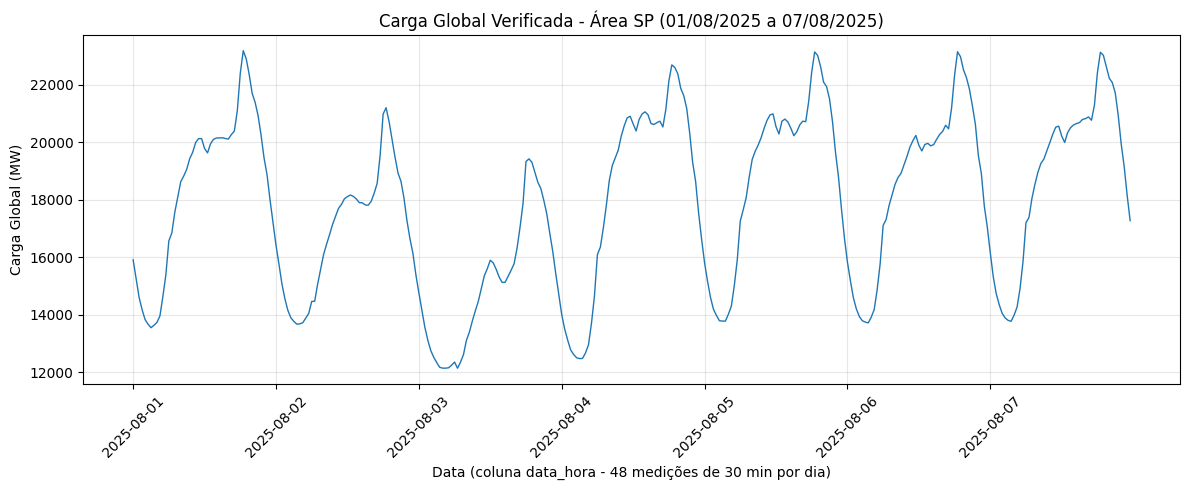

In [28]:
df_plot = df_carga.reset_index(drop=True)

dias = sorted(df_plot["data_hora"].unique())
posicoes_dia = [df_plot.index[df_plot["data_hora"] == d][0] for d in dias]

plt.figure(figsize=(12, 5))
plt.plot(df_plot.index, df_plot["carga_global"], color="#1f77b4", linewidth=1)
plt.xticks(posicoes_dia, dias, rotation=45)
plt.title("Carga Global Verificada - Área SP (01/08/2025 a 07/08/2025)")
plt.xlabel("Data (coluna data_hora - 48 medições de 30 min por dia)")
plt.ylabel("Carga Global (MW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico mostra a carga global oscilando de forma cíclica ao longo dos sete dias, entre 12139,25 MW e 23185,31 MW. Cada dia repete um padrão semelhante de vale e pico, característico de uma curva de carga diária. Os patamares mais altos aparecem de forma recorrente, porém por trechos curtos, enquanto na maior parte do tempo a carga se mantém em níveis intermediários, próximos da média de 17870,83 MW.

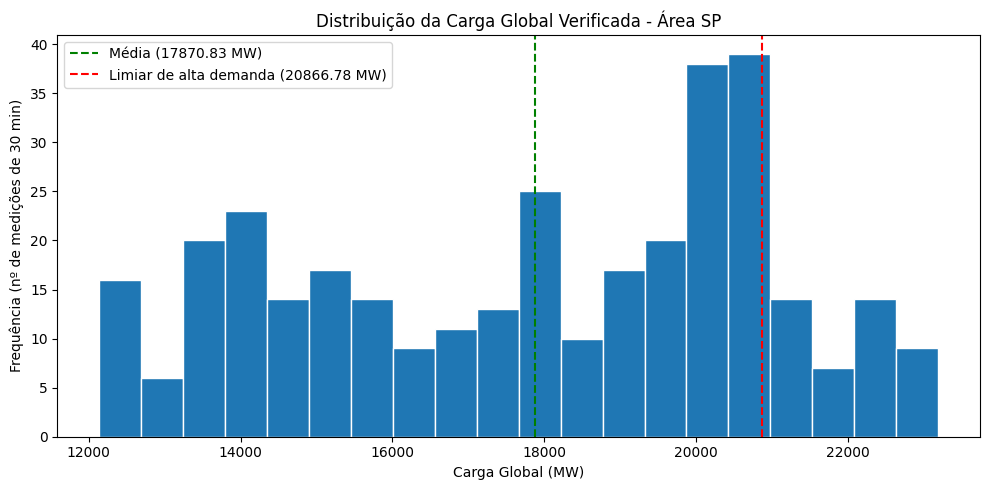

In [29]:
carga_maxima = df_carga["carga_global"].max()
limiar_90 = carga_maxima * 0.90
carga_media = df_carga["carga_global"].mean()

plt.figure(figsize=(10, 5))
plt.hist(df_carga["carga_global"], bins=20, color="#1f77b4", edgecolor="white")
plt.axvline(carga_media, color="green", linestyle="--",
            label=f"Média ({carga_media:.2f} MW)")
plt.axvline(limiar_90, color="red", linestyle="--",
            label=f"Limiar de alta demanda ({limiar_90:.2f} MW)")
plt.title("Distribuição da Carga Global Verificada - Área SP")
plt.xlabel("Carga Global (MW)")
plt.ylabel("Frequência (nº de medições de 30 min)")
plt.legend()
plt.tight_layout()
plt.show()

O histograma mostra que as medições se espalham por toda a faixa de 12139,25 a 23185,31 MW, sem concentração forte em um único intervalo. A linha da média (17870,83 MW) fica próxima do centro da distribuição, e apenas a cauda à direita da linha vermelha (limiar de 20866,78 MW) corresponde à alta demanda — 50 das 336 medições. O gráfico confirma o resultado do DESAFIO 4: os valores próximos ao pico são pouco frequentes.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [30]:
carga_min = df_carga["carga_global"].min()
carga_mediana = df_carga["carga_global"].median()

resumo_resultados = f'''
Região analisada: {df_carga["area_carga"].iloc[0]}
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {total_registros}
Carga mínima: {carga_min:.2f} MW
Carga máxima: {carga_maxima:.2f} MW
Carga média: {carga_media:.2f} MW
Mediana: {carga_mediana:.2f} MW
Limiar de alta demanda (90% do máximo): {limiar_alta_demanda:.2f} MW
Registros de alta demanda: {qtd_alta_demanda} ({pct_alta_demanda:.2f}%)
Momento do pico: {data_pico} às {horario_pico_local.strftime('%H:%M')} (horário de Brasília)
Segundo critério (carga acima da média): {qtd_segundo_criterio} registros ({pct_segundo_criterio:.2f}%)
'''

print(resumo_resultados)


Região analisada: SP
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda (90% do máximo): 20866.78 MW
Registros de alta demanda: 50 (14.88%)
Momento do pico: 2025-08-01 às 19:00 (horário de Brasília)
Segundo critério (carga acima da média): 184 registros (54.76%)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [31]:
!pip -q install -U google-genai

In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

**1. Os indicadores foram utilizados corretamente?**

Em grande parte, sim. Os valores citados nas seções 2 e 3 (mínima 12.139,25 MW, máxima 23.185,31 MW, amplitude 11.046,06 MW, média 17.870,83 MW, mediana 18.199,13 MW, limiar de 20.866,78 MW, 50 registros de alta demanda / 14,88%, pico de 23.185,31 MW em 01/08 às 19h) reproduzem exatamente o que foi calculado nos DESAFIOs 3 e 4.

Há, porém, um uso incorreto na seção 4: o texto trata os 184 registros "acima da média" (54,76%) como "praticamente o mesmo grupo" dos 50 registros de "alta demanda" (14,88%). Isso é um erro — os 50 registros de alta demanda estão contidos dentro dos 184, mas representam apenas cerca de 27% deles. São recortes de abrangência bem diferente, não grupos equivalentes.

**2. Há alguma afirmação que não pode ser confirmada pelos dados?**

Sim, duas:

- A explicação causal do pico ("retorno das pessoas para casa... chuveiros elétricos, iluminação e demais equipamentos residenciais") não pode ser sustentada pelos dados disponíveis. O dataset só contém área de carga, data/hora e valores de carga (MW) — não há informação sobre tipo de consumidor ou uso final de energia.
- A "tendência de crescimento da demanda... concentrados no final do período" também não se confirma. A média diária de carga foi: 01/08 (sex.) = 18.495,32 MW; 02/08 (sáb.) = 16.904,03 MW; 03/08 (dom.) = 15.036,06 MW; 04/08 (seg.) = 18.342,84 MW; 05/08 (ter.) = 18.882,60 MW; 06/08 (qua.) = 18.577,32 MW; 07/08 (qui.) = 18.857,63 MW. Não há crescimento monotônico: o valor máximo absoluto da semana ocorreu já no primeiro dia (01/08), e o padrão observado é queda no fim de semana, não crescimento ao final do período.

**3. Houve interpretação exagerada ou causalidade não demonstrada?**

Sim, nos mesmos três pontos: causalidade não demonstrada ao atribuir o pico a comportamentos residenciais específicos; interpretação exagerada ao ler um padrão semanal cíclico (dias úteis vs. fim de semana) como tendência linear de crescimento; e interpretação exagerada ao equiparar os dois critérios de recorte (14,88% vs. 54,76%) como "praticamente o mesmo grupo". Vale registrar também uma imprecisão terminológica: "consumo de energia" (MWh) foi usado como sinônimo de "carga" (MW), grandezas fisicamente diferentes.

**4. Que alterações a equipe realizou no texto?**

- Substituímos "praticamente o mesmo grupo" pela comparação numérica correta: os 50 registros de alta demanda são um subconjunto dos 184 acima da média, mas correspondem a apenas ~27% deles.
- Removemos a atribuição causal ao comportamento residencial como fato, reformulando-a como hipótese explicitamente não confirmável com os dados atuais.
- Removemos a afirmação de tendência de crescimento e a substituímos pela observação (essa sim sustentada pelos dados) de um padrão cíclico dia útil / fim de semana, com o pico máximo absoluto já no primeiro dia analisado.
- Padronizamos a terminologia, usando "carga" (MW) em vez de "consumo de energia".
- Mantivemos a estrutura das 5 seções e os demais indicadores, que estavam corretos.

---

## Relatório final revisado

**Relatório Técnico — Carga Elétrica Verificada, Área SP (01/08/2025 a 07/08/2025)**

**1. Caracterização do conjunto analisado**
Foram analisados 336 registros de carga elétrica global verificada na área SP (ONS), medidos em intervalos de 30 minutos, cobrindo sete dias completos: de sexta-feira (01/08/2025) a quinta-feira (07/08/2025).

**2. Principais indicadores**
- Carga mínima: 12.139,25 MW
- Carga máxima: 23.185,31 MW
- Amplitude: 11.046,06 MW
- Carga média: 17.870,83 MW
- Mediana: 18.199,13 MW

O máximo fica cerca de 30% acima da média e o mínimo cerca de 32% abaixo dela — distância proporcional semelhante dos dois lados. Como média e mediana diferem em apenas ~2%, o valor máximo não representa um evento atípico isolado, mas sim uma variação esperada dentro do ciclo diário de carga.

**3. Períodos de alta demanda**
Considerando alta demanda como os registros acima de 90% da carga máxima (limiar de 20.866,78 MW), foram identificados 50 registros — 14,88% do total, equivalente a 25 das 168 horas analisadas. O pico da semana ocorreu em 01/08/2025 às 19h (horário de Brasília), com 23.185,31 MW. Os horários de alta demanda concentram-se recorrentemente por volta das 18h30–21h em praticamente todos os dias, indicando um padrão diário consistente — uma **observação**, não uma explicação causal, já que os dados não trazem informação sobre o que compõe essa carga.

**4. Comparação com o segundo critério**
O segundo recorte (carga acima da média de 17.870,83 MW) reúne 184 registros — 54,76% do total. Os 50 registros de alta demanda estão contidos nesse grupo, mas correspondem a apenas ~27% dele: são recortes de abrangência bem diferente, não grupos equivalentes. "Operar acima da média" é uma condição frequente (mais da metade das medições); "operar em alta demanda" é bem mais restrito.

A média diária ao longo da semana (sex. 18.495; sáb. 16.904; dom. 15.036; seg. 18.343; ter. 18.883; qua. 18.577; qui. 18.858 MW) não mostra tendência linear de crescimento — mostra um padrão cíclico entre dias úteis e fim de semana, com queda visível no sábado e, principalmente, no domingo. O valor máximo absoluto da semana ocorreu já no primeiro dia analisado.

**5. Conclusão**
No período de 01 a 07/08/2025, a área SP apresentou uma curva de carga com comportamento cíclico diário (pico recorrente por volta das 19h) e um padrão semanal marcado por queda de demanda no fim de semana. Os períodos de alta demanda (>90% do pico) são pouco frequentes (14,88% do tempo) e não devem ser confundidos com os períodos "acima da média", bem mais abrangentes (54,76%). Os dados não permitem atribuir causas específicas às variações observadas — qualquer explicação nesse sentido é hipótese, não conclusão, e exigiria dados adicionais (composição da carga por classe de consumidor, variáveis climáticas etc.) para ser testada.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**